In [14]:
#By Cristian Cruz 
pip install scapy
!pip install pyx cryptography

     ---------------------------------------- 0.0/628.9 kB ? eta -:--:--
     ------------------------------- ------ 524.3/628.9 kB 4.2 MB/s eta 0:00:01
     ---------------------------------------- 628.9/628.9 kB 2.9 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   --------- ------------------------------ 0.8/3.5 MB 4.2 MB/s eta 0:00:01
   ------------------ --------------------- 1.6/3.5 MB 4.2 MB/s eta 0:00:01
   ------------------------------ --------- 2.6/3.5 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 4.3 MB/s  0:00:00
  Created wheel for pyx: filename=pyx-0.17-py3-none-any.whl size=447


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from scapy.all import *

In [48]:
#Creamos un paquete loopback IP
paquete = IP(ttl=10)
print(type(paquete))
print(paquete)


<class 'scapy.layers.inet.IP'>
127.0.0.1 > 127.0.0.1 ip


In [49]:
print("Dirección IP de origen:", paquete.src)
print("Dirección IP de destino:",paquete.dst)
print("TTL:",paquete.ttl)
#si se elimina el campo ttl, se reestablece a 64c
del(paquete.ttl)
print("TTL:",paquete.ttl)

Dirección IP de origen: 127.0.0.1
Dirección IP de destino: 127.0.0.1
TTL: 10
TTL: 64


In [57]:
# Creación de un paquete IP con TTL = 10
paquete = IP(ttl=10)

# Asignación de la dirección IP de origen y destino
paquete.src = "10.23.213.20"
paquete.dst = "8.8.8.8"

print("Dirección IP de origen:", paquete.src)
print("Dirección IP de destino:", paquete.dst)

#Parámetros del paquete
paquete.show()

Dirección IP de origen: 10.23.213.20
Dirección IP de destino: 8.8.8.8
###[ IP ]###
  version   = 4
  ihl       = None
  tos       = 0x0
  len       = None
  id        = 1
  flags     = 
  frag      = 0
  ttl       = 10
  proto     = ip
  chksum    = None
  src       = 10.23.213.20
  dst       = 8.8.8.8
  \options   \



## Apilamiento de Capas

El apilamiento de capas significa que puedes combinar diferentes protocolos en un solo paquete. Cada capa representa un protocolo diferente en el modelo OSI o TCP/IP, como IP, TCP, UDP, ICMP, etc. Las capas superiores de la pila utilizan las capas inferiores para el transporte y la entrega de datos.

# Ejemplo básico de apilamiento de capas:

Imagina que quieres crear un paquete que tenga las siguientes capas:

Capa 3 (Red): Un paquete IP
Capa 4 (Transporte): Un paquete TCP
Capa 5 (Aplicación): Datos del protocolo HTTP

Scapy te permite apilar estos protocolos fácilmente, con cada capa agregando más detalles y funcionalidad al paquete. Para ello se emplea el operador (/)
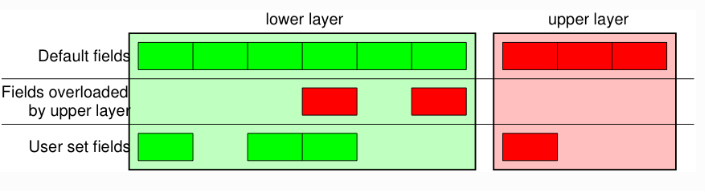

In [59]:
IP()

<IP  |>

In [60]:
IP()/TCP()

<IP  frag=0 proto=tcp |<TCP  |>>

In [61]:
Ether()/IP()/TCP()

<Ether  type=IPv4 |<IP  frag=0 proto=tcp |<TCP  |>>>

In [62]:
IP()/TCP()/"GET / HTTP/1.0\r\n\r\n"

<IP  frag=0 proto=tcp |<TCP  |<Raw  load=b'GET / HTTP/1.0\r\n\r\n' |>>>

In [63]:
Ether()/IP()/IP()/UDP()

<Ether  type=IPv4 |<IP  frag=0 proto=4 |<IP  frag=0 proto=udp |<UDP  |>>>>

In [64]:
IP(proto=55)/TCP()

<IP  frag=0 proto=55 |<TCP  |>>

In [75]:
##Representación cruda, de un paquete IP
raw(IP())

#raw() en  convierte un paquete o cualquier capa en una secuencia de bytes crudos

b'E\x00\x00\x14\x00\x01\x00\x00@\x00|\xe7\x7f\x00\x00\x01\x7f\x00\x00\x01'

In [76]:
IP(_)

<IP  version=4 ihl=5 tos=0x0 len=20 id=1 flags= frag=0 ttl=64 proto=ip chksum=0x7ce7 src=127.0.0.1 dst=127.0.0.1 |>

In [77]:
a=Ether()/IP(dst="www.slashdot.org")/TCP()/"GET /index.html HTTP/1.0 \n\n"
print(a)

Ether / IP / TCP 10.23.213.20:ftp_data > Net("www.slashdot.org/32"):http S / Raw


In [78]:
hexdump(a)

0000  F6 A4 E1 1C 3C 2F 20 4E F6 09 9C 0B 08 00 45 00  ....</ N......E.
0010  00 43 00 01 00 00 40 06 2E A0 0A 17 D5 14 68 12  .C....@.......h.
0020  04 D7 00 14 00 50 00 00 00 00 00 00 00 00 50 02  .....P........P.
0030  20 00 71 9D 00 00 47 45 54 20 2F 69 6E 64 65 78   .q...GET /index
0040  2E 68 74 6D 6C 20 48 54 54 50 2F 31 2E 30 20 0A  .html HTTP/1.0 .
0050  0A                                               .


In [80]:
b=raw(a)
print(b)

b'\xf6\xa4\xe1\x1c</ N\xf6\t\x9c\x0b\x08\x00E\x00\x00C\x00\x01\x00\x00@\x06.\xa0\n\x17\xd5\x14h\x12\x04\xd7\x00\x14\x00P\x00\x00\x00\x00\x00\x00\x00\x00P\x02 \x00q\x9d\x00\x00GET /index.html HTTP/1.0 \n\n'


In [82]:
Ether(b)


<Ether  dst=f6:a4:e1:1c:3c:2f src=20:4e:f6:09:9c:0b type=IPv4 |<IP  version=4 ihl=5 tos=0x0 len=67 id=1 flags= frag=0 ttl=64 proto=tcp chksum=0x2ea0 src=10.23.213.20 dst=104.18.4.215 |<TCP  sport=ftp_data dport=http seq=0 ack=0 dataofs=5 reserved=0 flags=S window=8192 chksum=0x719d urgptr=0 |<Raw  load=b'GET /index.html HTTP/1.0 \n\n' |>>>>

## Construir un paquete de solicitud hacia google

In [82]:
#Paso 1: Identificar las capas y los protocolos involucrados
#Segun el modelo TCP/IP
#1: capa de aplicación (HTTP)
#2: capa de transporte (TCP)
#3: Capa de red (IP)
#4: capa de enlace de datos (Ethernet)


#1: En la capa de aplicación
http_request = b"GET / HTTP/1.1\r\nHost: www.google.com\r\n\r\n"

#2: Capa de transporte
# - puerto 80 es el puerto HTTP estándar.
# - flags: 'S' para SYN (sincronización de conexión).
#tcp = TCP(dport=80, sport=RandShort(), flags="S", seq=1000)
tcp = TCP(dport=80, sport=22726, flags="S", seq=1000)
#3: Capa de red (IP)
ip = IP(dst="192.168.16.137")  # Dirección IP de Google (puedes usar la función 'gethostbyname' para buscarla automáticamente)

#4: Construimos el paquete
paquete = ip/tcp

# Enviar el paquete SYN y esperar la respuesta (SYN-ACK)
respuesta = sr1(paquete, timeout=10)
respuesta.show()





Received 2 packets, got 1 answers, remaining 0 packets
###[ IP ]###
  version   = 4
  ihl       = 5
  tos       = 0x0
  len       = 44
  id        = 0
  flags     = DF
  frag      = 0
  ttl       = 64
  proto     = tcp
  chksum    = 0x98f1
  src       = 192.168.16.137
  dst       = 192.168.16.1
  \options   \
###[ TCP ]###
     sport     = http
     dport     = 22726
     seq       = 1427541711
     ack       = 1001
     dataofs   = 6
     reserved  = 0
     flags     = SA
     window    = 64240
     chksum    = 0xba65
     urgptr    = 0
     options   = [('MSS', 1460)]
###[ Padding ]###
        load      = b'\x00\x00'



In [83]:
# Responder con un paquete ACK para completar el handshake
tcp_ack = TCP(dport=respuesta.sport, sport=respuesta.dport, flags="A", seq=respuesta.ack, ack=respuesta.seq + 1)
ack_paquete = ip/tcp_ack
respuesta_ack = sr1(ack_paquete, timeout=10)
respuesta_ack.show()


Received 2 packets, got 1 answers, remaining 0 packets
###[ IP ]###
  version   = 4
  ihl       = 5
  tos       = 0x0
  len       = 40
  id        = 0
  flags     = DF
  frag      = 0
  ttl       = 64
  proto     = tcp
  chksum    = 0x98f5
  src       = 192.168.16.137
  dst       = 192.168.16.1
  \options   \
###[ TCP ]###
     sport     = http
     dport     = 22726
     seq       = 1427541712
     ack       = 0
     dataofs   = 5
     reserved  = 0
     flags     = R
     window    = 0
     chksum    = 0xd108
     urgptr    = 0
     options   = []
###[ Padding ]###
        load      = b'\x00\x00\x00\x00\x00\x00'



In [49]:
# Enviar la solicitud HTTP (GET) real
http_request_paquete = ip/TCP(dport=80, sport=22726, flags="A", seq=respuesta_ack.seq, ack=respuesta_ack.seq + len(http_request)) / http_request
respuesta_http = sr1(http_request_paquete)
respuesta_http.show()



Received 2 packets, got 1 answers, remaining 0 packets
###[ IP ]###
  version   = 4
  ihl       = 5
  tos       = 0x28
  len       = 40
  id        = 0
  flags     = DF
  frag      = 0
  ttl       = 103
  proto     = tcp
  chksum    = 0x8d13
  src       = 216.58.207.46
  dst       = 10.23.213.20
  \options   \
###[ TCP ]###
     sport     = http
     dport     = 22726
     seq       = 3683041488
     ack       = 0
     dataofs   = 5
     reserved  = 0
     flags     = R
     window    = 0
     chksum    = 0x33de
     urgptr    = 0
     options   = []

###[ IP ]###
  version   = 4
  ihl       = 5
  tos       = 0x28
  len       = 40
  id        = 0
  flags     = DF
  frag      = 0
  ttl       = 103
  proto     = tcp
  chksum    = 0x8d13
  src       = 216.58.207.46
  dst       = 10.23.213.20
  \options   \
###[ TCP ]###
     sport     = http
     dport     = 22726
     seq       = 3683041488
     ack       = 0
     dataofs   = 5
     reserved  = 0
     flags     = R
     window    = 0
  